Dataset Shape: (6362620, 3)

Fraud Distribution
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
0.1291 %

Transaction Types
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud Rate By Transaction Type (%)
type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

Average Amount
isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64


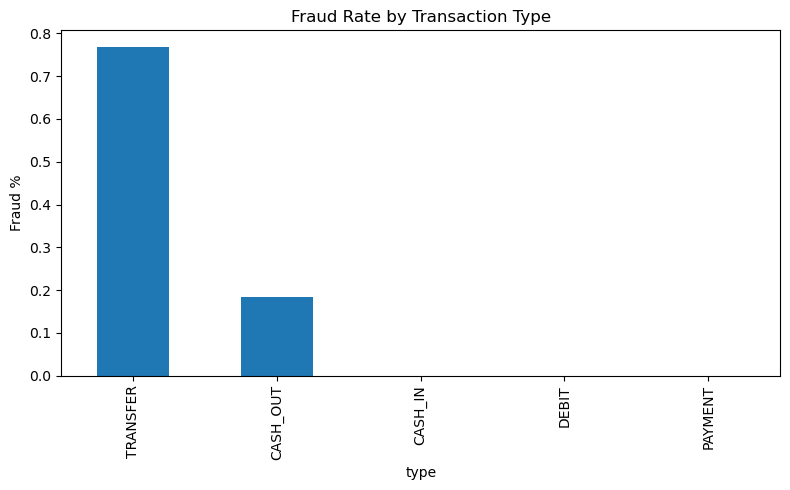

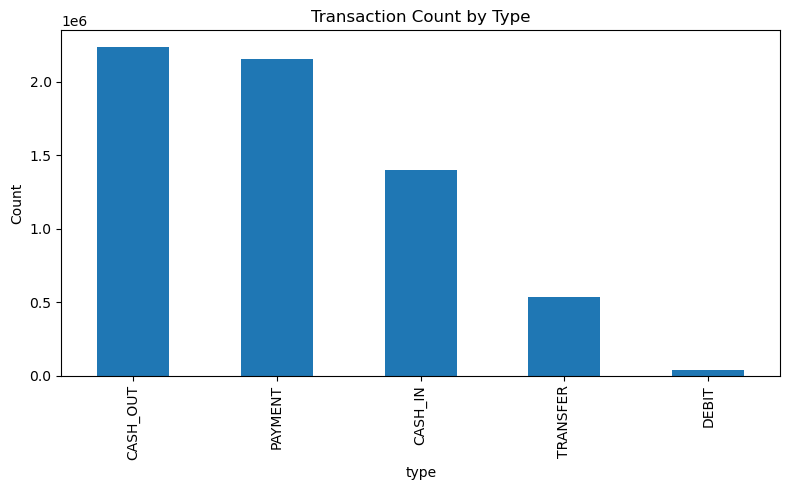

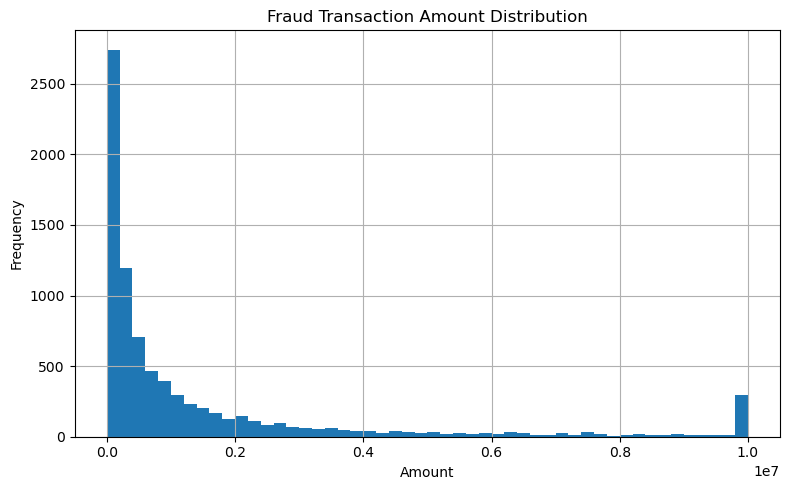

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "PS_20174392719_1491204439457_log.csv",
    usecols=["type","amount","isFraud"]
)

print("Dataset Shape:", df.shape)

print("\nFraud Distribution")
print(df["isFraud"].value_counts())

fraud_percent = (df["isFraud"].sum()/len(df))*100

print("\nFraud Percentage:")
print(round(fraud_percent,4),"%")

print("\nTransaction Types")
print(df["type"].value_counts())

fraud_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)*100
)

print("\nFraud Rate By Transaction Type (%)")
print(fraud_by_type)

avg_amount = (
    df.groupby("isFraud")["amount"]
    .mean()
)

print("\nAverage Amount")
print(avg_amount)

plt.figure(figsize=(8,5))
fraud_by_type.plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud %")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
df["type"].value_counts().plot(kind="bar")
plt.title("Transaction Count by Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
df[df["isFraud"]==1]["amount"].hist(bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()